<a href="https://colab.research.google.com/github/manashvishaw-cmd/mnsit--classification/blob/main/loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score


In [6]:
from google.colab import files
uploaded = files.upload()

Saving loan.csv to loan (1).csv


In [7]:
loan_dataset = pd.read_csv('loan.csv')

In [9]:
type(loan_dataset)

pandas.core.frame.DataFrame

In [10]:
loan_dataset.shape

(614, 13)

In [11]:
loan_dataset.describe()
loan_dataset.isnull().sum()
loan_dataset.isnull().sum()
loan_dataset.replace({"Loan_Status": {'N': 0, 'Y': 1}}, inplace=True)

/tmp/ipykernel_1677/968561357.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({"Loan_Status": {'N': 0, 'Y': 1}}, inplace=True)


In [12]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [13]:
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [14]:
loan_dataset = loan_dataset.replace(to_replace='3+', value=4)

loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
4,51


<Axes: xlabel='Education', ylabel='count'>

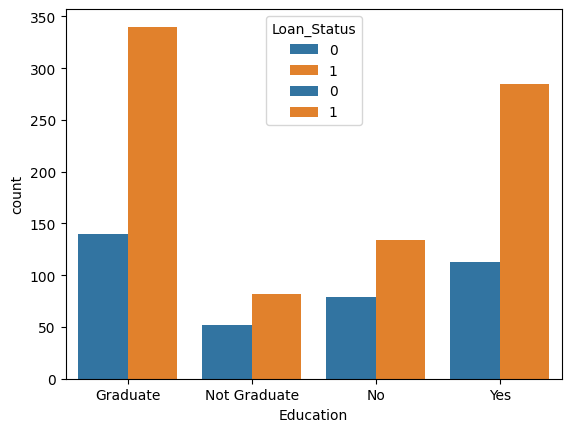

In [16]:
sns.countplot(x='Education', hue='Loan_Status', data=loan_dataset)

sns.countplot(x='Married', hue='Loan_Status', data=loan_dataset
)

In [18]:
loan_dataset.replace({
    'Married': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 1, 'Female': 0},
    'Self_Employed': {'No': 0, 'Yes': 1},
    'Property_Area': {'Rural': 0, 'Semiurban': 1, 'Urban': 2},
    'Education': {'Graduate': 1, 'Not Graduate': 0}
}, inplace=True)
loan_dataset.head()

/tmp/ipykernel_1677/158046214.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1


In [17]:
X = loan_dataset.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
Y = loan_dataset['Loan_Status']

print(X)
print(Y)

     Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes          4      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No             7583   
613  Female      No          0      Graduate           Yes             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, stratify=Y, random_state=2
)

print(X.shape, X_train.shape, X_test.shape)

(614, 11) (552, 11) (62, 11)


In [19]:
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)

NameError: name 'X_train' is not defined

In [22]:
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy on training data : ', training_data_accuracy)

X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy on test data : ', test_data_accuracy)

NotFittedError: This SVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [21]:
def predict_loan_status(input_data):
    """
    input_data: list/tuple in the order:
    [Gender, Married, Dependents, Education, Self_Employed,
     ApplicantIncome, CoapplicantIncome, LoanAmount,
     Loan_Amount_Term, Credit_History, Property_Area]
    """
    input_array = np.asarray(input_data).reshape(1, -1)
    prediction = classifier.predict(input_array)
    return "Approved" if prediction[0] == 1 else "Rejected"